In [14]:
import os
import time 
import numpy as np
import pandas as pd
from utils import get_one_fitness, LargeScenario

def get_collision_details(fitness_file):
    root = fitness_file.replace('fitness.csv','')
    folders = os.listdir(root)
    folders.sort()
    folders = [folder for folder in folders if 'routes_' in folder ]
    start_points = []
    end_points = []
    speeds = []
    for folder in folders:
        real_route  = pd.read_csv(root+folder+'/real_route.csv').to_numpy()
        speeds.append(np.load(root+folder+'/v.npy')[-1])
        start_points.append(real_route[0]) 
        end_points.append(real_route[-1])
        
    # fitness_header = ["DOL","DVE",'DVE-d',"DPD","DSM","DFD"]
    fitness_header = ["DOL","DVE",'DVE-d','DVE-x','DVE-y',"DPD","DSM","DFD"]

    fitness = pd.read_csv(fitness_file,names=fitness_header)
    # fitness['DVE-d'] = fitness['DVE-d'].apply(lambda data: float(data[:-1]))
    fitness['DVE-d'] = fitness['DVE-d'].apply(lambda data: float(data))
    fitness['DVE-x'] = fitness['DVE-x'].apply(lambda data: float(data))
    fitness['DVE-y'] = fitness['DVE-y'].apply(lambda data: float(data[:-1]))
    
    collision_direction = fitness['DVE-d']
    collision_position  = list(zip(fitness['DVE-x'], fitness['DVE-y']))

    collision_details = {
        'start_points': np.array(start_points),
        'end_points': np.array(collision_position),
        'speeds': np.array(speeds),
        'collision_direction': np.array(collision_direction)
    }
    return collision_details

def str_to_timestamp(time_str, format="%Y-%m-%d|%H:%M:%S"):
    return time.mktime(time.strptime(time_str[:19], "%Y-%m-%d|%H:%M:%S"))

def filt_folders(folders, start_time, end_time):
    start_timestamp =  str_to_timestamp(start_time)
    end_timestamp =  str_to_timestamp(end_time)
    result = []
    for folder in folders:
        if str_to_timestamp(folder) >= start_timestamp and str_to_timestamp(folder) <= end_timestamp:
            result.append(folder)
    return result

def collision_standardize(features):
    features[:, 0] = np.clip(features[:, 0], 25, 115)
    features[:, 1] = np.clip(features[:, 1], 55, 145)
    features[:, 2] = np.clip(features[:, 2], 0, 6)
    features[:, 3] = np.clip(features[:, 3], -180, 270)
    # 标准化位置和速度
    features[:, 0] = (features[:, 0]-25)  / 90  # 假设位置在25-115范围内
    features[:, 1] = (features[:, 1]-55)  / 90  # 假设位置在55-145范围内
    features[:, 2] = (features[:, 2]-0)   / 6   # 假设速度在0-6 m/s范围内
    features[:, 3] = (features[:, 3]+180) / 450 # 将碰撞方向标准化到-180-270范围内
    return features

def load_data(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    folders = os.listdir(root)
    folders.sort()
    folders = filt_folders(folders, start, end)

    fitnesses = []
    scenarios = []
    features = np.array([])
    for folder in folders:
        path = "{}/{}/".format(root, folder)
        fitnesses.append(get_one_fitness(path+'criterion.csv', path+'fitness.csv', col='CollisionTest'))
        
        collision_details = get_collision_details(path+'fitness.csv')

        collision_features = collision_details['end_points'][:, :2]
        collision_features = np.concatenate((collision_features, collision_details['speeds'][:, np.newaxis], collision_details['collision_direction'][:, np.newaxis]), axis=1)
        collision_features = collision_standardize(collision_features)
        # print(collision_features)
        if len(features) == 0:
            features = collision_features
        else:
            features = np.concatenate([features, collision_features])
        # print(path+'fitness.csv')
        # print(get_collision_details(path+'fitness.csv'))
        # print(collision_features)
        scenarios.append(LargeScenario(path))
    
    X = np.array([])
    for scenario in scenarios:
        if len(X) == 0:
            X = scenario.data
        else:
            X = np.concatenate([X, scenario.data], axis=0)

    y = np.array([])
    for fitnesse in fitnesses:
        if len(y) == 0:
            y = fitnesse
        else:
            y = np.concatenate([y, fitnesse], axis=0)
    
    
    return X, y, features

In [20]:
start = '2026-03-09|15:08:44'
end   = '2026-03-09|22:41:34'

x, y, z = load_data(start=start, end=end)
print(x.shape,y.shape,z.shape)
np.savez("random_data_1.npz", x=x, y=y, z=z)
# # filt_folders(start_time=start, end_time=end)

(140, 71) (140,) (140, 4)


In [24]:
a = []
a += []
a

[]

In [10]:
X.shape

(140, 71)

In [12]:
y.shape

(140,)

In [ ]:
import numpy as np


def elementwise_similarity(x,y,threshold=0.1):
    similarity = np.zeros((x.shape[0], y.shape[0]))
    for i, s1 in enumerate(x):
        for j, s2 in enumerate(y):
            similarity[i, j] = ((s2-s1)**2 < threshold**2).mean()
    return similarity

def local_elementwise_similarity(x,y,threshold=0.1, a=5):
    mask = np.array([1]*11+([1]*a+[0]*(15-a))*4)
    mask = mask/mask.sum()*71

    similarity = np.zeros((x.shape[0], y.shape[0]))
    for i, s1 in enumerate(x):
        for j, s2 in enumerate(y):
            similarity[i, j] = (((s2-s1)**2 < threshold**2)*mask).mean()
    return similarity

def _similarity(simi_func, fail, x):
    # print(fail.shape,fail.shape[0], fail.shape[0]==0)
    if fail.shape[0] == 0:
        return np.array([0]*len(x))
    else:
        return simi_func(np.array(fail), np.array(x)).max(axis=0)
    # return np.dot(x1, x2) / (np.linalg.norm(x1) * np.linalg.norm(x2))




In [29]:
x = np.random.rand(10,71).tolist()
unique_fail_cases = np.random.rand(3,71).tolist()+[x[0]]

In [ ]:
mask*x

array([[0.38724623, 0.99045795, 1.56408617, 2.1730542 , 0.86978036,
        2.15995486, 2.16616115, 2.11870165, 2.22436494, 1.43132887,
        1.62092821, 0.81135287, 1.9983296 , 1.2322515 , 2.05360984,
        0.37797459, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.66214799, 0.45009373, 1.53499145, 2.0530695 ,
        0.09668396, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 2.10199261, 0.33803207, 0.06089574, 0.28606767,
        2.06692515, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.03752623, 1.61284351, 0.46090579, 2.216755  ,
        0.23364033, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.59670712, 2.13868

: 

In [30]:
np.array(x).shape

(10, 71)

In [ ]:
elementwise_similarity(np.array(unique_fail_cases), np.array(x))

array([[1.        , 0.22535211, 0.12676056, 0.15492958, 0.11267606,
        0.1971831 , 0.26760563, 0.15492958, 0.11267606, 0.22535211],
       [0.22535211, 1.        , 0.18309859, 0.18309859, 0.16901408,
        0.18309859, 0.1971831 , 0.25352113, 0.29577465, 0.1971831 ],
       [0.12676056, 0.18309859, 1.        , 0.18309859, 0.1971831 ,
        0.16901408, 0.1971831 , 0.1971831 , 0.15492958, 0.14084507],
       [0.15492958, 0.18309859, 0.18309859, 1.        , 0.21126761,
        0.22535211, 0.12676056, 0.18309859, 0.07042254, 0.1971831 ],
       [0.11267606, 0.16901408, 0.1971831 , 0.21126761, 1.        ,
        0.15492958, 0.1971831 , 0.14084507, 0.16901408, 0.23943662],
       [0.1971831 , 0.18309859, 0.16901408, 0.22535211, 0.15492958,
        1.        , 0.18309859, 0.15492958, 0.14084507, 0.15492958],
       [0.26760563, 0.1971831 , 0.1971831 , 0.12676056, 0.1971831 ,
        0.18309859, 1.        , 0.14084507, 0.22535211, 0.25352113],
       [0.15492958, 0.25352113, 0.1971831

In [31]:
np.array(unique_fail_cases).shape

(4, 71)

In [32]:
_similarity(elementwise_similarity, np.array(unique_fail_cases), np.array(x))

array([1.        , 0.25352113, 0.22535211, 0.25352113, 0.18309859,
       0.21126761, 0.26760563, 0.21126761, 0.22535211, 0.22535211])

In [2]:
import os
import time
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold, train_test_split

from utils import get_one_fitness, LargeScenario

def str_to_timestamp(time_str, format="%Y-%m-%d|%H:%M:%S"):
    return time.mktime(time.strptime(time_str[:19], "%Y-%m-%d|%H:%M:%S"))

def filt_folders(folders, start_time, end_time):
    start_timestamp =  str_to_timestamp(start_time)
    end_timestamp =  str_to_timestamp(end_time)
    result = []
    for folder in folders:
        if '.' in folder:
            continue
        if str_to_timestamp(folder) >= start_timestamp and str_to_timestamp(folder) <= end_timestamp:
            result.append(folder)
    return result

def load_data(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    # root = '/home/guannan/Projects/SBT-data/InterFuser'
    folders = os.listdir(root)
    folders.sort()
    folders = filt_folders(folders, start, end)

    fitnesses = []
    scenarios = []

    for folder in folders:
        path = "{}/{}/".format(root, folder)
        # print(path)
        fitnesses.append(get_one_fitness(path+'criterion.csv', path+'fitness.csv', col='CollisionTest'))
        scenarios.append(LargeScenario(path))
    
    X = np.array([])
    for scenario in scenarios:
        if len(X) == 0:
            X = scenario.data
        else:
            X = np.concatenate([X, scenario.data], axis=0)

    y = np.array([])
    for fitnesse in fitnesses:
        if len(y) == 0:
            y = fitnesse
        else:
            y = np.concatenate([y, fitnesse], axis=0)
    return X, y


# 定义小型神经网络
class SmallNet(nn.Module):
    def __init__(self, input_dim):
        super(SmallNet, self).__init__()
        # self.fc_64   = nn.Linear(input_dim, 64) # 第一层，全连接
        # self.relu    = nn.ReLU()                # ReLU 激活函数
        # self.dropout = nn.Dropout(0.1)          # Dropout 防止过拟合
        # self.fc_32   = nn.Linear(64, 32)        # 第二层，全连接
        # self.fc_out  = nn.Linear(32, 1)         # 输出层，单个回归值
        self.fc_64   = nn.Linear(input_dim, 128)  # 第一层，全连接
        self.relu    = nn.ReLU()                  # ReLU 激活函数
        self.dropout = nn.Dropout(0.1)            # Dropout 防止过拟合
        self.fc_32   = nn.Linear(128, 64)         # 第二层，全连接
        self.fc_out  = nn.Linear(64, 1)           # 输出层，单个回归值


    def forward(self, x):
        x = self.fc_64(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc_32(x)
        x = self.relu(x)

        x = self.fc_out(x)
        return torch.sigmoid(x)  # 输出值在 0-1 范围内

# 自定义加权损失函数
def weighted_mse_loss(output, target):
    # y=0 的样本权重更高
    weights = torch.where(target == 0, 5.0, 1.0)
    # weights = torch.where(target < 0.1, (1-target)*10, 1.0)
    # weights = torch.where(target < 0.5, 1-target, target)
    # weights = torch.where(target < 0.1, 1.0, 1.0)
    loss = weights * (output - target) ** 2
    return loss.mean()

def pairwise_rank_loss(output, target):
    # 计算目标值和预测值的差
    diff_target = target - target.T  # Target 的差
    diff_output = output - output.T  # Output 的差

    # 计算排序损失：如果 diff_target 和 diff_output 符号不一致，则 penalize
    loss = torch.mean(torch.relu(-diff_target * diff_output))  # relu 确保非负
    return loss

def combined_loss(output, target):
    weights = [10,0]
    return (weights[0]*weighted_mse_loss(output, target) + weights[1]*pairwise_rank_loss(output, target))/sum(weights)


def train(root = '/home/guannan/Projects/SBT-data/InterFuser', start='2025-02-17|16:00:00', end='2025-02-18|03:50:00'):
    X, y = load_data(root, start, end)
    # 数据集（占位）
    # 使用你的数据，替换 X 和 y
    # X: shape = (num_samples, 71), y: shape = (num_samples,)
    X = X.astype(np.float32)  # 随机生成特征
    y = y.astype(np.float32)  # 随机生成标签

    # 转换为 PyTorch 张量
    X_tensor = torch.tensor(X)
    y_tensor = torch.tensor(y).view(-1, 1)

    # 超参数
    input_dim = X.shape[1]
    batch_size = 16
    num_epochs = 100
    learning_rate = 0.001

    # K 折交叉验证
    kf = KFold(n_splits=5)
    fold_mse = []


    X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.33, random_state=42)
    # for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        # print(f"Fold {fold + 1}")
        
        # # 划分训练集和验证集
        # X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
        # y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]
        
    # 数据加载器
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 初始化模型、损失函数和优化器
    model = SmallNet(input_dim=input_dim)
    # criterion = weighted_mse_loss
    # criterion = pairwise_rank_loss
    criterion = combined_loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 训练模型
    best_val_loss = float('inf')
    best_val_mse_loss = float('inf')
    early_stop_counter = 0
    patience = 10
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 验证模型
        model.eval()
        val_loss = 0.0
        val_mse_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_mse_loss += weighted_mse_loss(outputs, y_batch).item()
        
        val_loss /= len(val_loader)
        val_mse_loss /= len(val_loader)
        # print(f"Epoch {epoch + 1}: Train Loss = {train_loss / len(train_loader):.4f}, Val Loss = {val_loss:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_mse_loss = val_mse_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                # print("Early stopping triggered!")
                break
    
    # 保存每折的验证损失
    # fold_mse.append(best_val_loss)
    fold_mse.append(best_val_mse_loss)

    # 打印结果
    print("MSE:", np.mean(fold_mse))
    print("RMSE:", np.mean(fold_mse)**0.5)
    print(np.concatenate([np.array(outputs), np.array(y_batch)], axis=1))

    return model

In [7]:
root  = '/home/guannan/Projects/SBT-data/Back_up/2025-03-06 - surrogate test'
start = '2025-03-05|16:00:00'
end   = '2025-03-07|02:30:00'

model = train(root  = root , 
              start = start, 
              end   = end  )

MSE: 0.05855887702533177
RMSE: 0.2419894151101072
[[5.5236632e-01 5.2466291e-01]
 [3.7277362e-01 5.5029553e-01]
 [1.5079591e-01 0.0000000e+00]
 [9.5899835e-02 0.0000000e+00]
 [4.9540021e-02 1.6721979e-01]
 [2.9543257e-01 5.6705326e-01]
 [1.9302258e-04 0.0000000e+00]]


In [8]:
X, y = load_data(root, start, end)
X = X.astype(np.float32)  # 随机生成特征
y = y.astype(np.float32)  # 随机生成标签

# 转换为 PyTorch 张量
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y).view(-1, 1)

batch_size = 16
X_batch = X_tensor[:batch_size].clone()
y_batch = y_tensor[:batch_size].clone()
X_batch.requires_grad = True

# 数据加载器
# dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
# dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# np.savetxt('X_batch.csv', X_batch.detach().numpy(), delimiter=',')

In [9]:
y_hat = model(X_batch)
y_hat.backward(gradient=torch.ones_like(y_batch))

gard = X_batch.grad
X_batch.requires_grad=False

y_fuzzeds = []
X_fuzzed = X_batch.clone()
y_fuzzed = y_hat.clone()

e = 0.01 #epsilon
t = 0.05 #threshold of dangerous

for i in range(20):
    mask = y_fuzzed.squeeze() > t
    # print(X_fuzzed[:,:5])
    X_fuzzed[mask] = X_fuzzed[mask] - e*gard.sign()[mask]
    X_fuzzed[X_fuzzed <= 0 + 1e-3] = 0 + 1e-3 
    X_fuzzed[X_fuzzed >= 1 - 1e-3] = 1 - 1e-3

    y_fuzzed = model(X_fuzzed)
    y_fuzzeds.append(y_fuzzed)

    print(X_fuzzed.min(), X_fuzzed.max())

tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)
tensor(0.0010) tensor(0.9990)


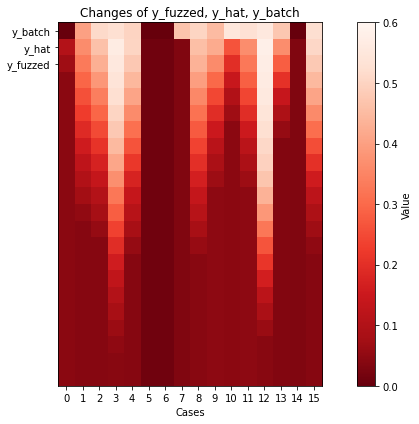

In [119]:
import matplotlib.pyplot as plt

y_compare = torch.concat([y_batch, y_hat]+y_fuzzeds, dim=1).detach().numpy().T

# 创建热力图
fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(y_compare, cmap='Reds_r', vmin=0, vmax=0.6)

# 设置坐标轴标签
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['y_batch', 'y_hat', 'y_fuzzed'])
ax.set_xticks(range(y_compare.shape[1]))
# ax.set_xticklabels(range(1, y_compare.shape[1] + 1), rotation=90)

# 添加颜色条
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Value')

# 美化图形
plt.title("Changes of y_fuzzed, y_hat, y_batch")
plt.xlabel("Cases")
plt.tight_layout()
plt.show()

In [120]:
# X_fuzzed.detach().numpy().tofile('X_fuzzed_20.csv', sep=',')
np.savetxt('X_fuzzed_20.csv', X_fuzzed.detach().numpy(), delimiter=',')

In [33]:
import numpy as np
np.loadtxt('X_fuzzed.csv', delimiter=',')

array([[0.43702197, 0.7403245 , 0.001     , ..., 0.92459476, 0.60655504,
        0.92340189],
       [0.20747474, 0.20927638, 0.87739122, ..., 0.6771217 , 0.62624019,
        0.20645526],
       [0.001     , 0.2213435 , 0.001     , ..., 0.29487571, 0.99900001,
        0.27395567],
       ...,
       [0.79689372, 0.54701293, 0.51887876, ..., 0.21380183, 0.59784675,
        0.40941665],
       [0.56466728, 0.98440343, 0.3217029 , ..., 0.12051068, 0.85244578,
        0.60834587],
       [0.63128769, 0.34829065, 0.39507848, ..., 0.48454738, 0.79584605,
        0.001     ]])

In [3]:
def get_y(root, start, end):
    _, y = load_data(root, start, end)
    y = y.astype(np.float32)  # 随机生成标签

    # 转换为 PyTorch 张量
    y_tensor = torch.tensor(y).view(-1, 1)

    return y_tensor


In [4]:
root  = '/home/guannan/Projects/SBT-data/InterFuser'

In [5]:
# y_1 = get_y(root, '2025-05-08|18:00:00', '2025-05-08|18:30:00')
# y_2 = get_y(root, '2025-05-08|18:30:00', '2025-05-08|19:00:00')
# y_3 = get_y(root, '2025-05-08|19:00:00', '2025-05-08|19:30:00')
# y_4 = get_y(root, '2025-05-08|19:30:00', '2025-05-08|20:00:00')
# y_5 = get_y(root, '2025-05-08|20:00:00', '2025-05-08|20:30:00')


y_1 = get_y(root, '2025-05-09|00:00:00', '2025-05-09|00:30:00')
y_2 = get_y(root, '2025-05-09|00:30:00', '2025-05-09|01:00:00')
y_3 = get_y(root, '2025-05-09|01:00:00', '2025-05-09|01:30:00')
y_4 = get_y(root, '2025-05-09|01:30:00', '2025-05-09|02:00:00')
y_5 = get_y(root, '2025-05-09|02:00:00', '2025-05-09|02:30:00')

In [6]:
y_true_1 = get_y(root, '2025-05-08|21:00:00', '2025-05-08|21:30:00')
y_true_2 = get_y(root, '2025-05-08|21:30:00', '2025-05-08|22:00:00')
y_true_3 = get_y(root, '2025-05-08|22:00:00', '2025-05-08|22:30:00')
y_true_4 = get_y(root, '2025-05-08|22:30:00', '2025-05-08|23:00:00')
y_true_5 = get_y(root, '2025-05-08|23:00:00', '2025-05-08|23:30:00')

In [8]:
root  = '/home/guannan/Projects/SBT-data/Back_up/TrueLabel'
folders = os.listdir(root)
folders.sort()

y_list_original = []
for folder in folders:
    y_list_original.append(get_y(root, folder, folder))
print(len(y_list_original))

y_compare_original = torch.concat(y_list_original, dim=1).detach().numpy().T

25


In [9]:
root  = '/home/guannan/Projects/SBT-data/Back_up/AttackOnce'
folders = os.listdir(root)
folders.sort()

y_list = []
for folder in folders:
    y_list.append(get_y(root, folder, folder))
print(len(y_list))

y_compare = torch.concat(y_list, dim=1).detach().numpy().T

25


In [82]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
# import seaborn as sns


p_values = []
significant_cases = []

for i in range(y_compare.shape[1]):  # 遍历每个 case
    if np.all(y_compare_original[:, i] == 0) and np.all(y_compare[:, i] == 0) and np.all(y_compare_original[:, i] == y_compare[:, i]):
        print(f"Case {i:02d}: 所有值完全相同，无法检验。")
        p_values.append(1.0)  # 设置 p 值为 1.0
        continue
    stat, p = mannwhitneyu(y_compare_original[:, i], y_compare[:, i], alternative='greater')  # before > after
    p_values.append(p)
    if p < 0.05:
        significant_cases.append(i)
    print(f"Case {i:02d}: U={stat:.2f}, p-value={p:.4f} {'<-- 显著' if p < 0.05 else ''}")

print("\n显著下降的 case:", significant_cases)

Case 00: U=337.50, p-value=0.0808 
Case 01: U=221.00, p-value=0.9629 
Case 02: U=458.50, p-value=0.0024 <-- 显著
Case 03: U=569.00, p-value=0.0000 <-- 显著
Case 04: U=310.00, p-value=0.5232 
Case 05: 所有值完全相同，无法检验。
Case 06: U=325.00, p-value=0.1685 
Case 07: U=267.00, p-value=0.8140 
Case 08: U=84.00, p-value=1.0000 
Case 09: U=608.00, p-value=0.0000 <-- 显著
Case 10: U=121.00, p-value=0.9999 
Case 11: U=479.00, p-value=0.0006 <-- 显著
Case 12: U=442.00, p-value=0.0062 <-- 显著
Case 13: U=108.00, p-value=1.0000 
Case 14: U=400.00, p-value=0.0413 <-- 显著
Case 15: U=469.00, p-value=0.0012 <-- 显著

显著下降的 case: [2, 3, 9, 11, 12, 14, 15]


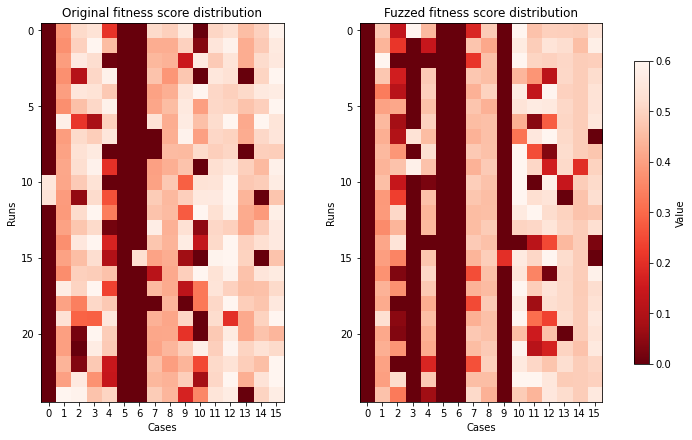

In [113]:
import matplotlib.pyplot as plt

# 假设 y_compare1 是原始的，y_compare2 是处理后的数据
# 请用你自己的变量名替换 y_compare1 和 y_compare2

fig, axes = plt.subplots(1, 2, figsize=(10, 6),  constrained_layout=True)  # 1行2列布局

# 左侧：原始分数
cax1 = axes[0].imshow(y_compare_original, cmap='Reds_r', vmin=0, vmax=0.6)
axes[0].set_title("Original fitness score distribution")
axes[0].set_xlabel("Cases")
axes[0].set_ylabel("Runs")
axes[0].set_xticks(range(y_compare_original.shape[1]))

# 右侧：处理后分数
cax2 = axes[1].imshow(y_compare, cmap='Reds_r', vmin=0, vmax=0.6)
axes[1].set_title("Fuzzed fitness score distribution")
axes[1].set_xlabel("Cases")
axes[1].set_ylabel("Runs")
axes[1].set_xticks(range(y_compare.shape[1]))

# 统一颜色条（共享）
fig.colorbar(cax2, ax=axes, shrink=0.8, orientation='vertical', label='Value')

# plt.tight_layout()
plt.show()


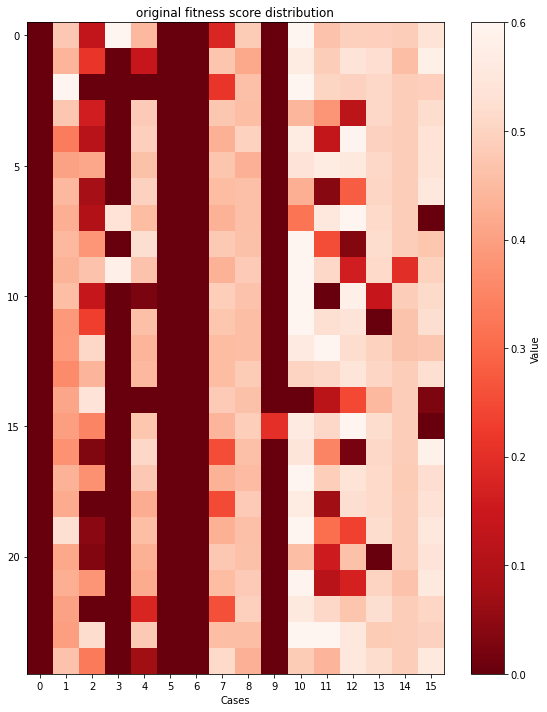

In [ ]:
import matplotlib.pyplot as plt

# 创建热力图
fig, ax = plt.subplots(figsize=(8, 10))
cax = ax.imshow(y_compare, cmap='Reds_r', vmin=0, vmax=0.6)

# 设置坐标轴标签
ax.set_xticks(range(y_compare.shape[1]))

# 添加颜色条
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Value')

# 美化图形
plt.title("Original fitness score distribution")
plt.xlabel("Cases")
plt.tight_layout()
plt.show()

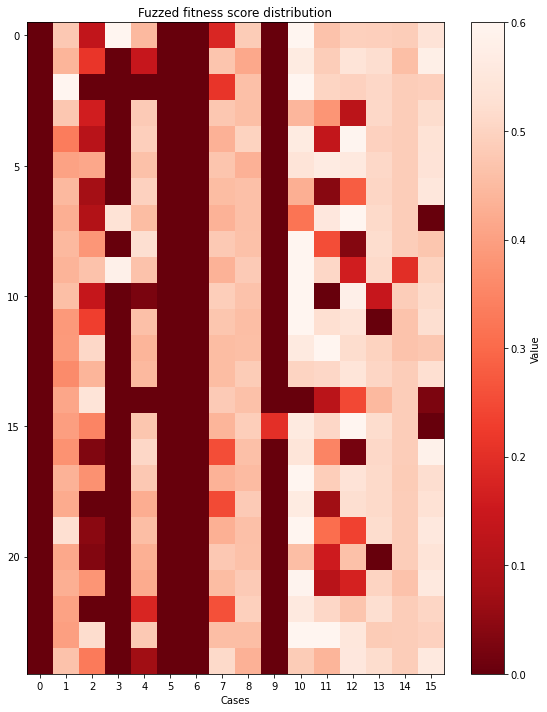

In [100]:
import matplotlib.pyplot as plt

# 创建热力图
fig, ax = plt.subplots(figsize=(8, 10))
cax = ax.imshow(y_compare, cmap='Reds_r', vmin=0, vmax=0.6)

# 设置坐标轴标签
ax.set_xticks(range(y_compare.shape[1]))

# 添加颜色条
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Value')

# 美化图形
plt.title("Fuzzed fitness score distribution")
plt.xlabel("Cases")
plt.tight_layout()
plt.show()

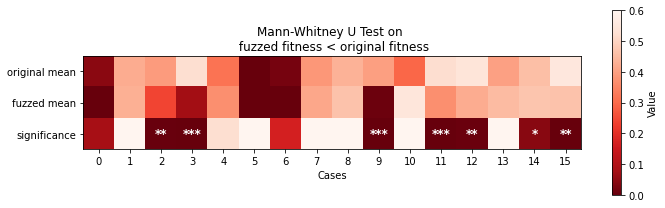

In [95]:
import matplotlib.pyplot as plt

# y_compare = torch.concat(y_list, dim=1).detach().numpy().T

# 创建热力图
fig, ax = plt.subplots(figsize=(10, 3))
cax = ax.imshow(np.array([y_compare_original.mean(axis=0), y_compare.mean(axis=0), np.array(p_values)]), cmap='Reds_r', vmin=0, vmax=0.6)

# 设置坐标轴标签
ax.set_yticks(range(3))
ax.set_yticklabels(['original mean', 'fuzzed mean', 'significance'])
ax.set_xticks(range(y_compare.shape[1]))

# 添加颜色条
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Value')


# 添加星号标注到 significance 行（行索引为 2）
for i, p in enumerate(p_values):
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    
    ax.text(i, 2, stars, ha='center', va='center', color='white', fontsize=12, fontweight='bold')


# 美化图形
plt.title("Mann-Whitney U Test on \n fuzzed fitness < original fitness")
plt.xlabel("Cases")
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt

root = '/home/guannan/Projects/SBT-data/Back_up/TrueLabel'
# root = '/home/guannan/Projects/SBT-data/Back_up/AttackOnce'
direction = 'bev'
index = 0
# start = True
start = False
# brightness = False
brightness = 0.25

/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_02_28/bev/0428.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:32:20/routes_courve_05_08_21_32_37/bev/0377.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|22:02:15/routes_courve_05_08_22_02_32/bev/0385.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|22:32:14/routes_courve_05_08_22_32_46/bev/0397.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|23:02:23/routes_courve_05_08_23_02_44/bev/0410.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-09|13:06:53/routes_courve_05_09_13_07_15/bev/0378.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-09|13:36:59/routes_courve_05_09_13_37_19/bev/0399.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-09|14:07:15/routes_courve_05_09_14_07_32/bev/0398.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-09|14:37:16/routes_courve_05_09_14_37_34/bev/0

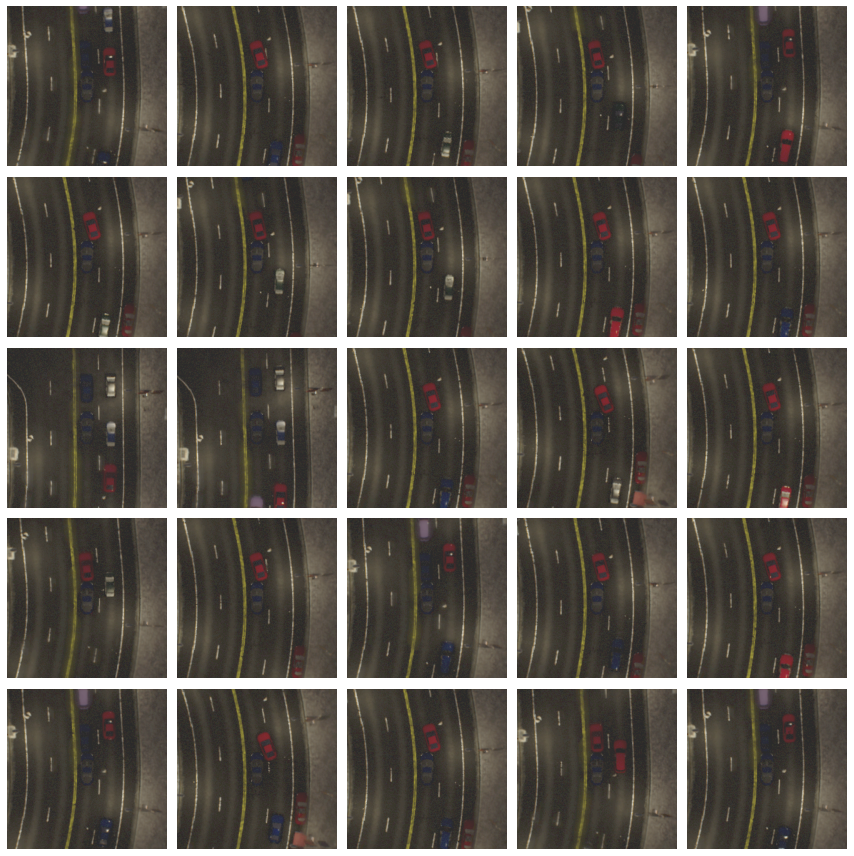

In [13]:
images = []

times = os.listdir(root)
times.sort()

for i, time in enumerate(times):
    cases = os.listdir("{}/{}".format(root, time))
    cases.sort()
    cases = [case for case in cases if '.' not in case]

    case = cases[index]
    path = "{}/{}/{}/{}".format(root, time, case, direction)

    image_list = os.listdir(path)
    image_list.sort()
    image_path = "{}/{}".format(path, image_list[0 if start else -1])
    print(image_path)

    img = plt.imread(image_path)
    img = img[128:384, 128:384, :3]
    if brightness:
        brighter_img = np.clip(img + brightness-img.mean(), 0, 1)
    else:
        brighter_img = img
    images.append(brighter_img)

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [36]:
import matplotlib.pyplot as plt

root_true   = '/home/guannan/Projects/SBT-data/Back_up/TrueLabel'
root_attack = '/home/guannan/Projects/SBT-data/Back_up/AttackOnce'
direction = 'bev'
# index = 10
# start = True
# start = False
# brightness = False
brightness = 0.25

In [37]:
images_true = []

timestemp = os.listdir(root_true)
timestemp.sort()

time = timestemp[0]
cases = os.listdir("{}/{}".format(root_true, time))
cases.sort()
cases = [case for case in cases if '.' not in case]

for case in cases:
    path = "{}/{}/{}/{}".format(root_true, time, case, direction)
    image_list = os.listdir(path)
    image_list.sort()
    image_path = "{}/{}".format(path, image_list[0])
    print(image_path)

    img = plt.imread(image_path)
    img = img[128:384, 128:384, :3]
    if brightness:
        brighter_img = np.clip(img + brightness-img.mean(), 0, 1)
    else:
        brighter_img = img
    images_true.append(brighter_img)

print()

images_attck = []

timestemp = os.listdir(root_attack)
timestemp.sort()

time = timestemp[0]
cases = os.listdir("{}/{}".format(root_attack, time))
cases.sort()
cases = [case for case in cases if '.' not in case]

for case in cases:
    path = "{}/{}/{}/{}".format(root_attack, time, case, direction)
    image_list = os.listdir(path)
    image_list.sort()
    image_path = "{}/{}".format(path, image_list[0])
    print(image_path)

    img = plt.imread(image_path)
    img = img[128:384, 128:384, :3]
    if brightness:
        brighter_img = np.clip(img + brightness-img.mean(), 0, 1)
    else:
        brighter_img = img
    images_attck.append(brighter_img)


/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_02_28/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_04_15/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_05_54/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_08_10/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_10_10/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_12_05/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_13_35/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_15_55/bev/0000.png
/home/guannan/Projects/SBT-data/Back_up/TrueLabel/2025-05-08|21:02:11/routes_courve_05_08_21_17_36/bev/0

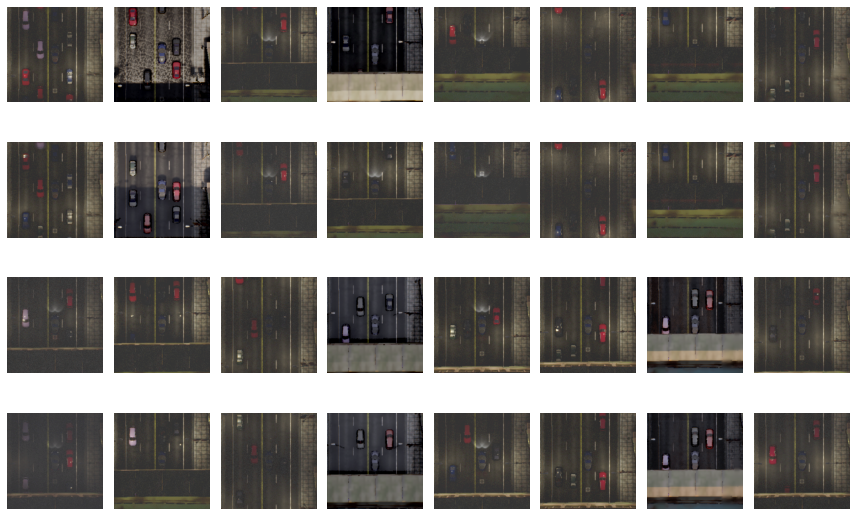

In [38]:
fig, axes = plt.subplots(4, 8, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    index = i % 8
    if i >= 16:
        index += 8
    # print(i, index) 
    if (i//8) % 2 == 0:
        ax.imshow(images_true[index])
        ax.axis('off')
        # ax.set_ylabel("True", fontsize=12, fontweight='bold', color='red')
    else:
        ax.imshow(images_attck[index])
        ax.axis('off')
        # ax.set_ylabel("Attack", fontsize=12, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

In [41]:
labels = ['','','**','***','','','','',
          '','***','','***','**','','*','***']

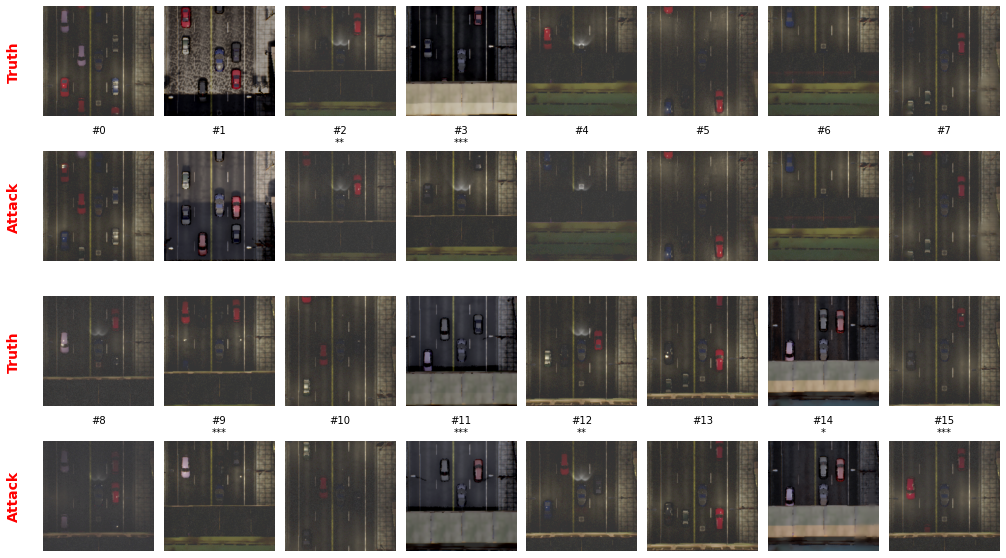

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 8, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    row = i // 8
    col = i % 8

    # 计算图片索引
    index = col
    if row >= 2:
        index += 8  # 后两行使用后面 8 张图

    # 加载对应图片
    if row % 2 == 0:
        ax.imshow(images_true[index])
    else:
        ax.imshow(images_attck[index])

    ax.axis('off')

    # 加标签（第1、3行为 Truth，第2、4行为 Attack）
    if col == 0:  # 只有每行最左边的图加标签
        label = 'Truth' if row % 2 == 0 else 'Attack'
        # ax.set_ylabel(label, fontsize=14, fontweight='bold', color='red', rotation=0, labelpad=30, va='center')
        ax.text(-0.2, 0.5, label, fontsize=14, fontweight='bold', color='red',
        ha='right', va='center', transform=ax.transAxes, rotation=90)
    # 第二、四行加 index
    if row % 2 == 1:
        ax.set_title(f"#{index}\n"+"{}".format(labels[index]), fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
"""
distance, training_min, train_sec, 1k_min, 1k_sec, date
3.01, 20, 17, 6, 43, 2025/05/08-18:38
3.02, 21, 12, 7, 1,  2025/05/06-18:49
3.03, 20, 58, 6, 54, 2025/05/05-18:08
3.04, 20, 23, 6, 41, 2025/05/04-22:01
4.02, 30, 6,  7, 28, 2025/03/26-21:57
3.03, 23, 13, 7, 39, 2025/03/25-22:02
"""